In [1]:
# import pandas
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\VISHAL\Desktop\Raw data\raw_data.csv")

In [3]:
# Divide customers into categories
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 36, 72],
    labels=['0-12', '13-36', '37+']
)

In [5]:
# check data types
print(df.dtypes)

customerID               str
gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges             str
Churn                    str
tenure_group        category
dtype: object


In [6]:
# change the data type
import pandas as pd


In [7]:
# change the data type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# Average charges by tenure
df.groupby('tenure_group')[['MonthlyCharges', 'TotalCharges']].mean()


,MonthlyCharges,TotalCharges
tenure_group,,
0-12,56.172023,276.621563
13-36,63.248195,1513.541756
37+,72.008730,4213.723192


In [9]:
# Churn rate by tenure
churn_tenure = df.groupby('tenure_group')['Churn'].value_counts(normalize=True)
print(churn_tenure)

tenure_group  Churn
0-12          No       0.523218
              Yes      0.476782
13-36         No       0.744612
              Yes      0.255388
37+           No       0.880706
              Yes      0.119294
Name: proportion, dtype: float64


In [10]:
df.groupby('tenure_group')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
tenure_group,,
0-12,0.523218,0.476782
13-36,0.744612,0.255388
37+,0.880706,0.119294


In [11]:
# Analyze churn rates by demographics
# gender vs churn
df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [13]:
# senior citizen vs churn
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [15]:
# payment method
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack()


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [16]:
# contract type 
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


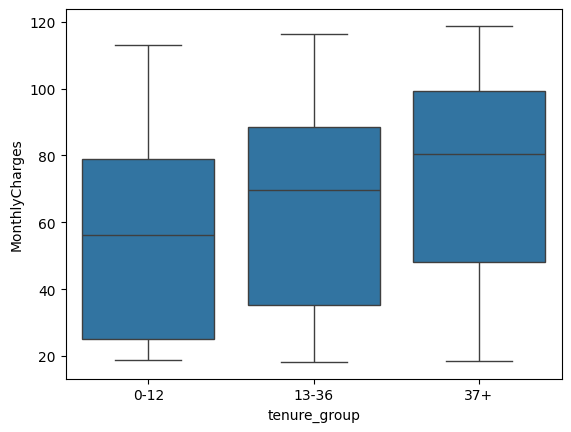

In [17]:
# visualization of Tenure vs Monthly Charges
#import seaborn & matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='tenure_group', y='MonthlyCharges', data=df)
plt.show()

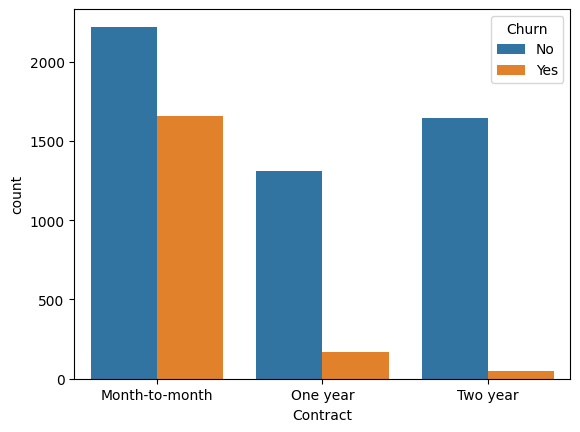

In [18]:
# Contract vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

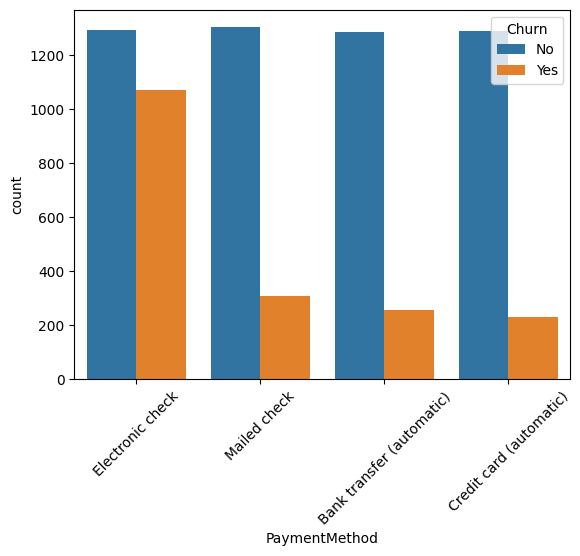

In [19]:
#Payment Method vs Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

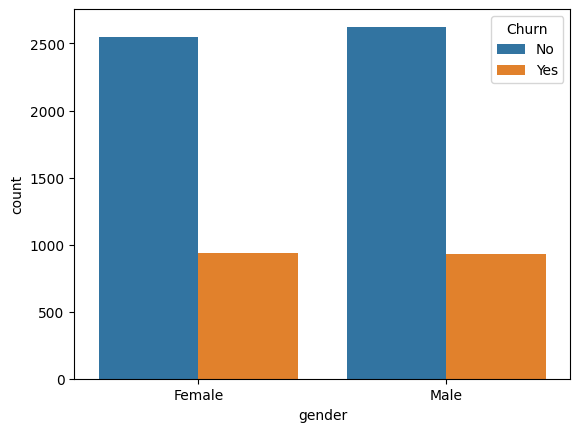

In [20]:
#Gender vs Churn
sns.countplot(x='gender', hue='Churn', data=df)
plt.show()

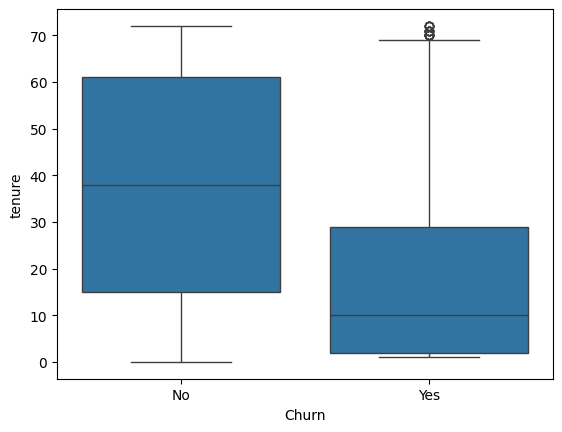

In [21]:
# Lifecycle / Trend Analysis
# Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

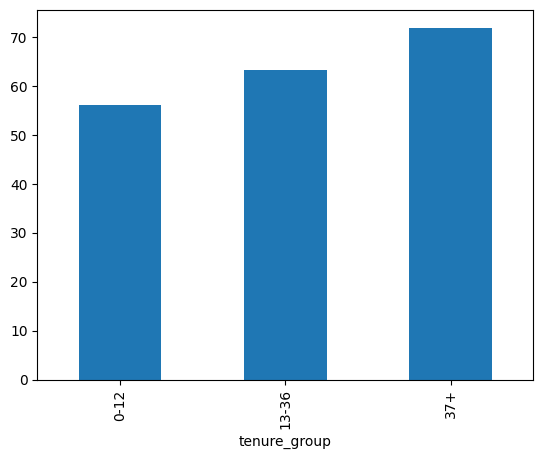

In [22]:
# Average charges over tenure
df.groupby('tenure_group')['MonthlyCharges'].mean().plot(kind='bar')
plt.show()